<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Auteconder_VAE_Pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import CIFAR10
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
#converte para tensor, normaliza os 3 canais e envia para o device
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.Lambda(lambda x: x.to(device))])
#baixando os datasets de treino e validação
train_DS = CIFAR10('./content_cifar', train=True, download=True, transform=img_transform)
val_DS = CIFAR10('./content_cifar', train=False, download=True, transform=img_transform)

100%|██████████| 170M/170M [14:02<00:00, 202kB/s]


In [4]:
class CIFARAutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        #encoder reduz 3072 feature
        self.encoder = nn.Sequential(
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(True),
            nn.Linear(512, 128),
            nn.ReLU(True),
            nn.Linear(128, latent_dim))
        #decoder reconstrói os dados de volta para 3072 features
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 512),
            nn.ReLU(True),
            nn.Linear(512, 3 * 32 * 32),
            nn.Tanh())
    def forward(self, x):
        # achata a imagem mantendo o batch size
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        #retorna ao formato original de imagem colorida
        x = x.view(len(x), 3, 32, 32)
        return x

In [5]:
#estrutura de otimização baseada em passos de gradiente e cálculo de erro por MSE Loss
def train_batch(input_data, model, optimizer, criterion):
    model.train()
    input_data = input_data.to(device)
    optimizer.zero_grad()
    output = model(input_data)
    loss = criterion(output, input_data)
    loss.backward()
    optimizer.step()
    return loss
@torch.no_grad()
def validate_batch(input_data, model, criterion):
    model.eval()
    input_data = input_data.to(device)
    output = model(input_data)
    loss = criterion(output, input_data)
    return loss

<div><p>Epoch 1: Train Loss=0.0837, Val Loss=0.0718</p><p>Epoch 2: Train Loss=0.0703, Val Loss=0.0703</p><p>Epoch 3: Train Loss=0.0690, Val Loss=0.0697</p><p>Epoch 4: Train Loss=0.0682, Val Loss=0.0695</p><p>Epoch 5: Train Loss=0.0676, Val Loss=0.0688</p></div>

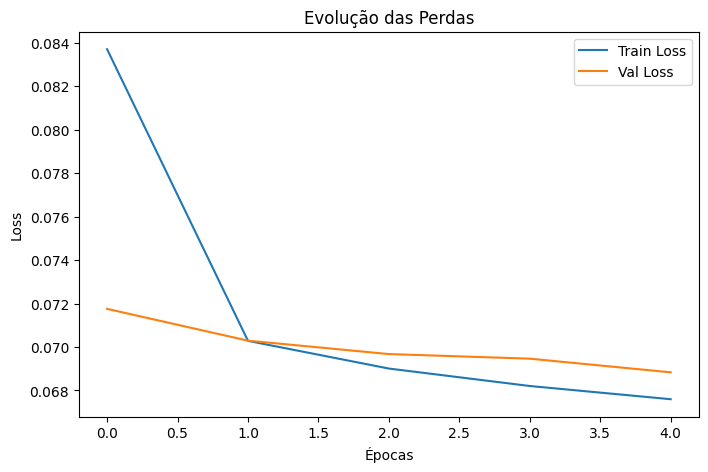

In [8]:
from fastprogress.fastprogress import master_bar, progress_bar
#modelo com 16 dimensões latentes
model = CIFARAutoEncoder(latent_dim=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
num_epochs = 5
train_losses, val_losses = [], []
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_DS, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_DS, batch_size=batch_size, shuffle=False)
mb = master_bar(range(num_epochs))
for epoch in mb:
    trn_loss_epoch = 0
    for ix, (data, _) in enumerate(progress_bar(train_loader, parent=mb)):
        loss = train_batch(data, model, optimizer, criterion)
        trn_loss_epoch += loss.item()
        mb.child.comment = f"Train Loss: {loss.item():.4f}"
    train_losses.append(trn_loss_epoch / len(train_loader))
    val_loss_epoch = 0
    for ix, (data, _) in enumerate(progress_bar(val_loader, parent=mb)):
        loss = validate_batch(data, model, criterion)
        val_loss_epoch += loss.item()
        mb.child.comment = f"Val Loss: {loss.item():.4f}"
    val_losses.append(val_loss_epoch / len(val_loader))

    mb.write(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")
# Gráfico de evolução da perda
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Evolução das Perdas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()